In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------
# Load ML-ready dataset
# ---------------------------
df = pd.read_excel('D:/Users/Rania/OneDrive - Universiti Teknologi PETRONAS/FYP/SmartTenaga/data/ml_ready_dataset_min2.xlsx')
df['created_at'] = pd.to_datetime(df['created_at'])

# ---------------------------
# 1. Basic dataset info
# ---------------------------
print("===== Dataset Info =====")
print(df.info())
print("\n===== First 5 Rows =====")
print(df.head())

# ---------------------------
# 2. Summary statistics
# ---------------------------
print("\n===== Summary Statistics =====")
print(df.describe())

# ---------------------------
# 3. Missing values
# ---------------------------
print("\n===== Missing Values per Column =====")
print(df.isna().sum())

# ---------------------------
# 4. Energy increment over time
# ---------------------------
plt.figure(figsize=(12,5))
plt.plot(df['created_at'], df['energy_increment_kwh'], alpha=0.7)
plt.title("Energy Increment Over Time")
plt.xlabel("Time")
plt.ylabel("Energy Increment (kWh)")
plt.tight_layout()
plt.show()

# ---------------------------
# 5. Approximate device contributions
# ---------------------------
device_columns = ['laptop','phone','lamp','ipad','monitor','powerbank','dryer','earbuds']

# Divide energy increment evenly among active devices per timestamp
df['active_devices_count'] = df[device_columns].sum(axis=1)
for dev in device_columns:
    # Only assign energy if device is active; divide by number of active devices
    df[f'{dev}_energy_est'] = df.apply(lambda row: row['energy_increment_kwh']/row['active_devices_count']
                                       if row[dev]==1 and row['active_devices_count']>0 else 0, axis=1)

# Sum estimated energy per device
device_energy_total = df[[f'{dev}_energy_est' for dev in device_columns]].sum().sort_values(ascending=False)
print("\n===== Estimated Total Energy per Device =====")
print(device_energy_total)

# Bar plot
plt.figure(figsize=(8,5))
sns.barplot(x=device_energy_total.index, y=device_energy_total.values, palette="magma")
plt.title("Estimated Energy Contribution per Device")
plt.ylabel("Total Energy (kWh)")
plt.xlabel("Device")
plt.tight_layout()
plt.show()

# ---------------------------
# 6. Device energy over time
# ---------------------------
plt.figure(figsize=(12,6))
for dev in device_columns:
    plt.plot(df['created_at'], df[f'{dev}_energy_est'], label=dev, alpha=0.7)
plt.title("Estimated Energy per Device Over Time")
plt.xlabel("Time")
plt.ylabel("Energy Increment (kWh)")
plt.legend()
plt.tight_layout()
plt.show()

# ---------------------------
# 7. Correlation heatmap
# ---------------------------
plt.figure(figsize=(12,10))
corr_cols = ['energy_increment_kwh'] + [f'{dev}_energy_est' for dev in device_columns]
sns.heatmap(df[corr_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation of Total Energy Increment with Estimated Device Energy")
plt.show()


===== Dataset Info =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5063 entries, 0 to 5062
Data columns (total 89 columns):
 #   Column                                Non-Null Count  Dtype         
---  ------                                --------------  -----         
 0   created_at                            5063 non-null   datetime64[ns]
 1   voltage                               5063 non-null   float64       
 2   current                               5063 non-null   float64       
 3   power                                 5063 non-null   float64       
 4   energy                                5063 non-null   float64       
 5   energy_increment_kwh                  5063 non-null   float64       
 6   energy_diff                           5063 non-null   float64       
 7   frequency                             5063 non-null   float64       
 8   power_factor                          5063 non-null   float64       
 9   status                                5063 non-nu

In [21]:
import pandas as pd

# Load dataset
df = pd.read_excel('D:/Users/Rania/OneDrive - Universiti Teknologi PETRONAS/FYP/SmartTenaga/data/ml_ready_dataset_min2.xlsx')
df['created_at'] = pd.to_datetime(df['created_at'])

# Device columns
device_columns = ['laptop','phone','lamp','ipad','monitor','powerbank','dryer','earbuds']

# Filter rows where exactly one device is active

df_single_device = df[df['is_active'] == 1]

# Initialize results
device_stats = []

for dev in device_columns:
    # Filter rows where this device is the only active one
    df_dev = df_single_device[df_single_device[dev] == 1]
    
    avg_power = df_dev['power'].mean()
    avg_energy_increment = df_dev['energy_increment_kwh'].mean()
    total_power = df_dev['power'].sum()
    total_energy_increment = df_dev['energy_increment_kwh'].sum()
    count = len(df_dev)
    
    device_stats.append({
        'device': dev,
        'count_only_active': count,
        'total_power': total_power,
        'avg_power': avg_power,
        'total_energy_increment': total_energy_increment,
        'avg_energy_increment': avg_energy_increment
    })

# Convert to DataFrame
device_stats_df = pd.DataFrame(device_stats).sort_values(by='avg_energy_increment', ascending=False)

print("\n===== Device Stats When Only Device is Active =====")
print(device_stats_df)



===== Device Stats When Only Device is Active =====
      device  count_only_active    total_power   avg_power  \
6      dryer                 38   11730.949963  308.709210   
4    monitor               2952  189844.866642   64.310592   
0     laptop               3912  217442.383342   55.583431   
3       ipad                752   40221.050003   53.485439   
1      phone               1065   56457.233310   53.011487   
5  powerbank                347   16830.249980   48.502161   
2       lamp               1581   64750.483333   40.955397   
7    earbuds                268    6964.116667   25.985510   

   total_energy_increment  avg_energy_increment  
6                0.192000              0.005053  
4                3.205216              0.001086  
0                3.781216              0.000967  
3                0.672000              0.000894  
1                0.937000              0.000880  
5                0.279000              0.000804  
2                1.117000             

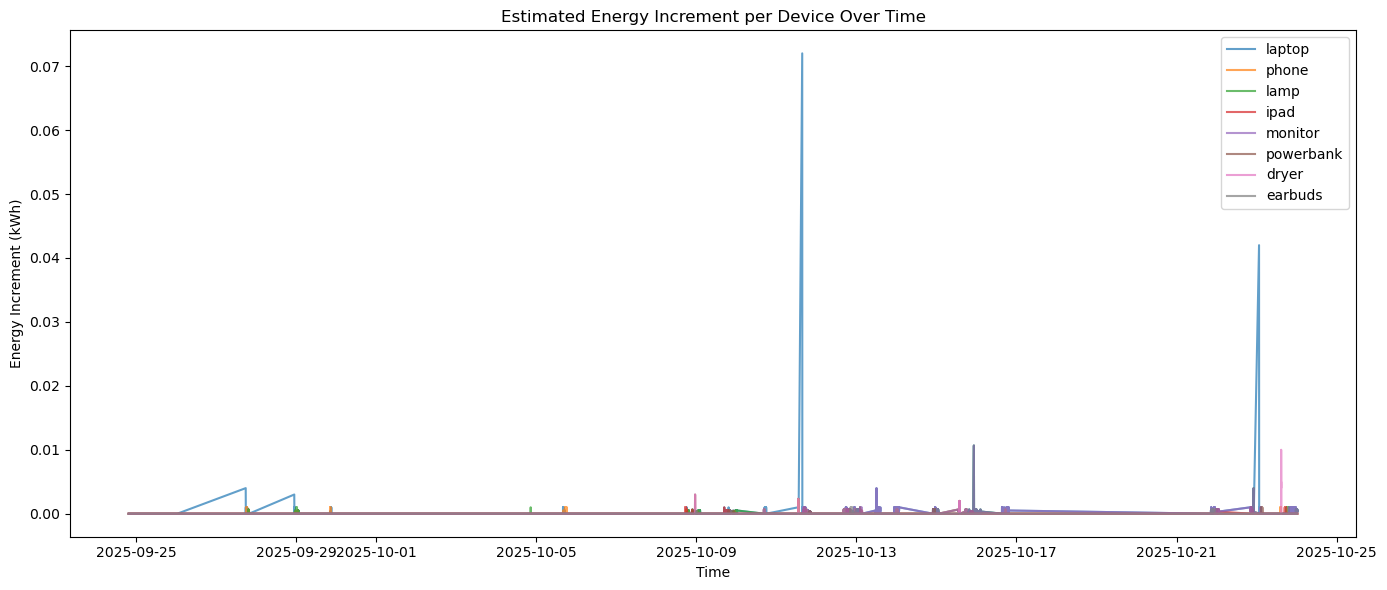

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_excel('D:/Users/Rania/OneDrive - Universiti Teknologi PETRONAS/FYP/SmartTenaga/data/ml_ready_dataset_min2.xlsx')
df['created_at'] = pd.to_datetime(df['created_at'])

# Device columns
device_columns = ['laptop','phone','lamp','ipad','monitor','powerbank','dryer','earbuds']

# Estimate per-device energy for each timestamp
df['active_devices_count'] = df[device_columns].sum(axis=1)
for dev in device_columns:
    df[f'{dev}_energy_est'] = df.apply(
        lambda row: row['energy_increment_kwh']/row['active_devices_count']
        if row[dev]==1 and row['active_devices_count']>0 else 0, axis=1
    )

# ---------------------------
# Time-series plot of device energy over time
# ---------------------------
plt.figure(figsize=(14,6))
for dev in device_columns:
    plt.plot(df['created_at'], df[f'{dev}_energy_est'], label=dev, alpha=0.7)

plt.title("Estimated Energy Increment per Device Over Time")
plt.xlabel("Time")
plt.ylabel("Energy Increment (kWh)")
plt.legend()
plt.tight_layout()
plt.show()


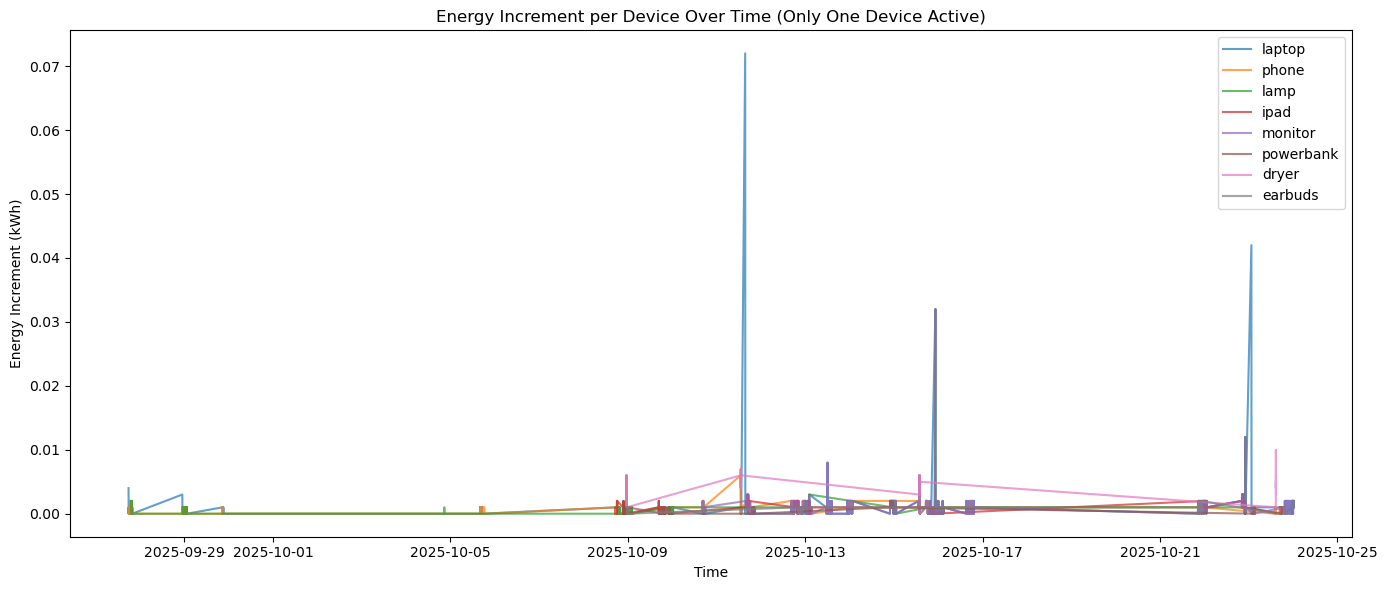

In [19]:
# Filter rows where only one device is active
df_single_device = df[df['is_active'] == 1]

plt.figure(figsize=(14,6))
for dev in device_columns:
    # Plot only timestamps where this device is the only one on
    df_dev = df_single_device[df_single_device[dev]==1]
    plt.plot(df_dev['created_at'], df_dev['energy_increment_kwh'], label=dev, alpha=0.7)

plt.title("Energy Increment per Device Over Time (Only One Device Active)")
plt.xlabel("Time")
plt.ylabel("Energy Increment (kWh)")
plt.legend()
plt.tight_layout()
plt.show()


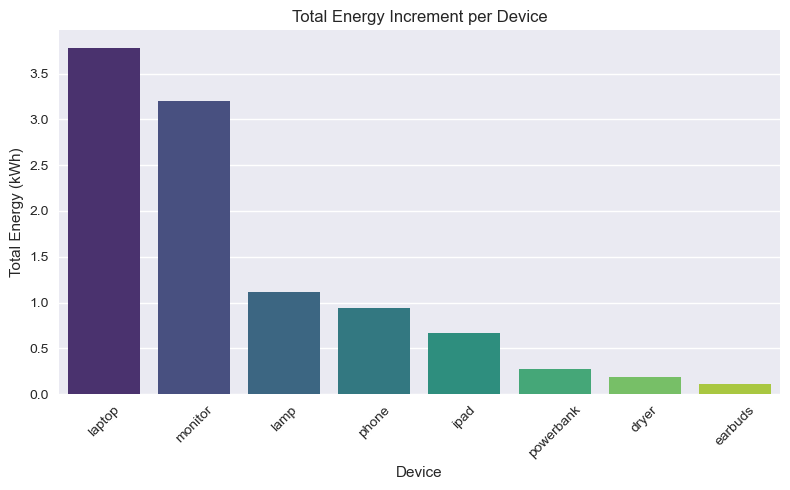

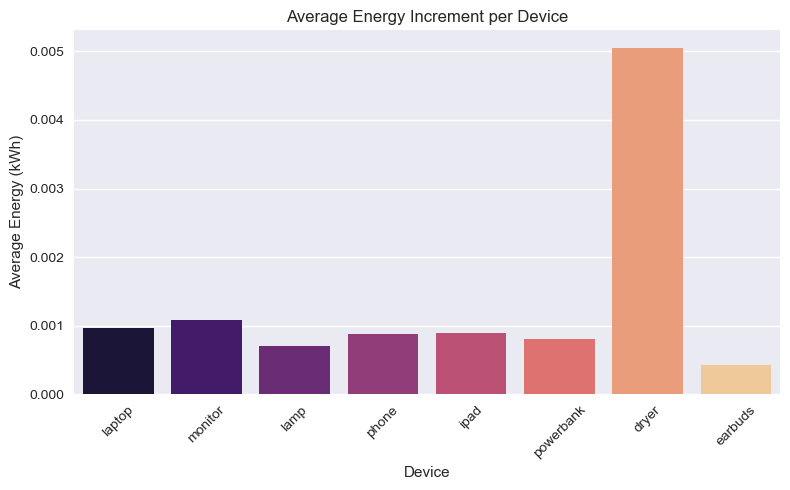

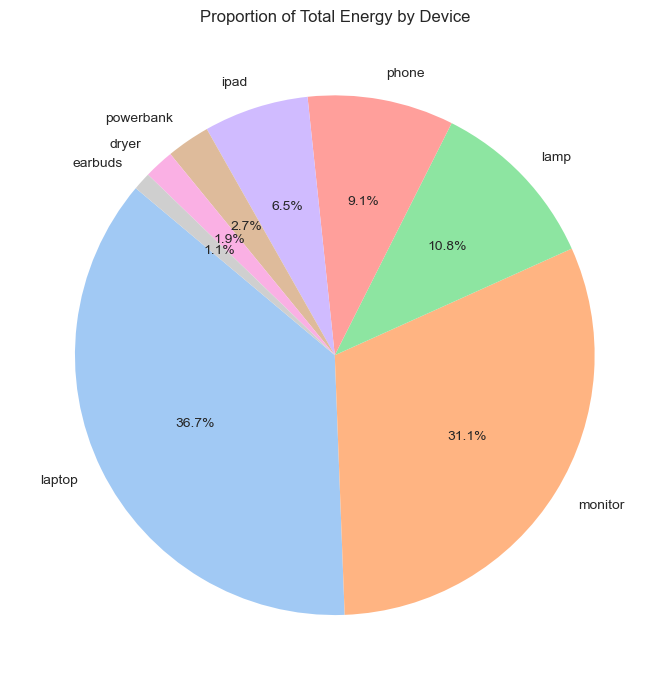

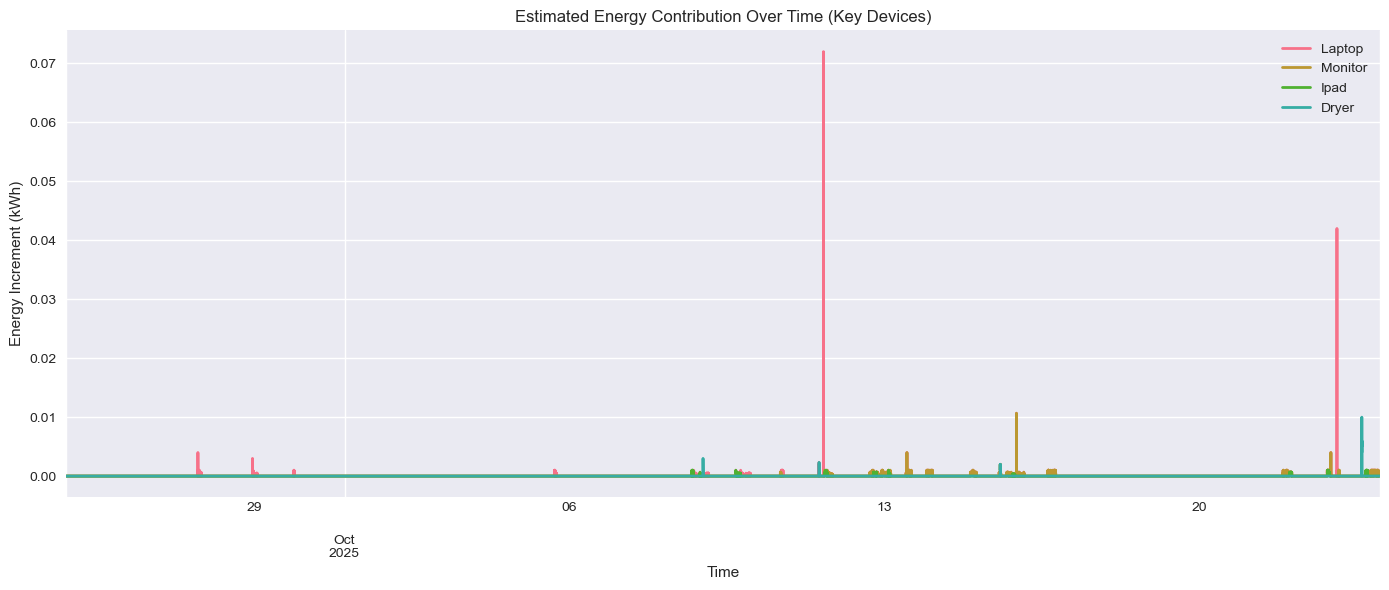

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sort devices by total_energy
summary_df = summary_df.sort_values(by='total_energy', ascending=False)

# ---------------------------
# 1. Total Energy per Device (Bar Chart)
# ---------------------------
plt.figure(figsize=(8,5))
sns.barplot(
    x='device',
    y='total_energy',
    data=summary_df,
    hue='device',
    palette='viridis',
    legend=False
)
plt.title("Total Energy Increment per Device")
plt.ylabel("Total Energy (kWh)")
plt.xlabel("Device")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ---------------------------
# 2. Average Energy per Device (Bar Chart)
# ---------------------------
plt.figure(figsize=(8,5))
sns.barplot(
    x='device',
    y='avg_energy',
    data=summary_df,
    hue='device',
    palette='magma',
    legend=False
)
plt.title("Average Energy Increment per Device")
plt.ylabel("Average Energy (kWh)")
plt.xlabel("Device")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ---------------------------
# 3. Proportion of Total Energy (Pie Chart)
# ---------------------------
plt.figure(figsize=(7,7))
plt.pie(summary_df['total_energy'], labels=summary_df['device'], autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title("Proportion of Total Energy by Device")
plt.tight_layout()
plt.show()

df_key_resampled.plot(kind='line', figsize=(14,6), linewidth=2)
plt.title("Estimated Energy Contribution Over Time (Key Devices)")
plt.xlabel("Time")
plt.ylabel("Energy Increment (kWh)")
plt.legend([dev.capitalize() for dev in key_devices])
plt.tight_layout()
plt.show()



===== Device Stats (Single-Device Timestamps) =====
      device  count_only_active  total_power   avg_power  \
0     laptop                235  6971.883333   29.667589   
6      dryer                  9  2835.450007  315.050001   
1      phone                199  2225.066667   11.181240   
3       ipad                 98  1838.283333   18.757993   
4    monitor                 37   804.966667   21.755856   
5  powerbank                 51   684.266667   13.416993   
2       lamp                149   672.016667    4.510179   
7    earbuds                132   302.200000    2.289394   

   total_energy_increment  avg_energy_increment  
0                   0.235              0.001000  
6                   0.045              0.005000  
1                   0.037              0.000186  
3                   0.031              0.000316  
4                   0.013              0.000351  
5                   0.012              0.000235  
2                   0.011              0.000074  
7     

C:\Users\Rania\AppData\Local\Temp\ipykernel_27740\2073147018.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='device', y='avg_energy_increment', data=device_stats_df, palette='viridis')


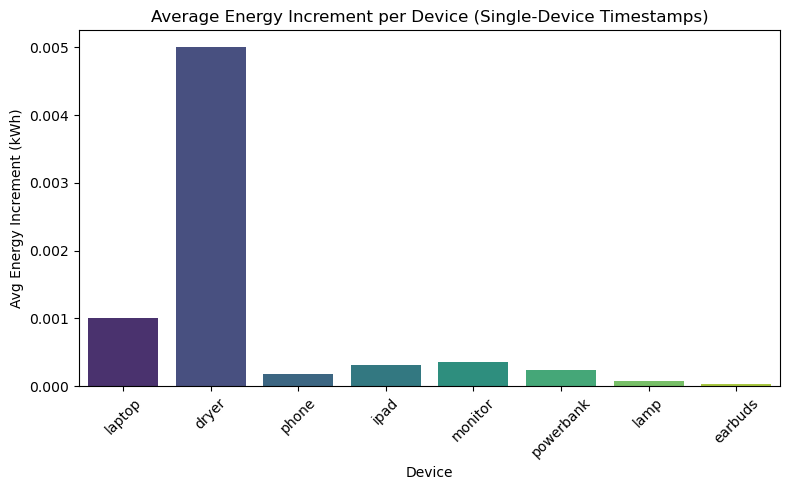

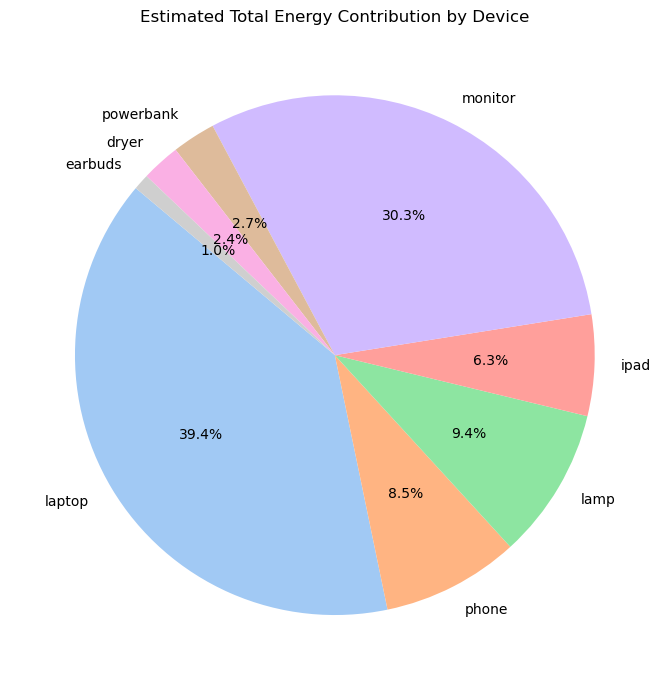

C:\Users\Rania\AppData\Local\Temp\ipykernel_27740\2073147018.py:78: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df_key_resampled = df_key.resample('1T').sum()  # resample to 1-minute intervals


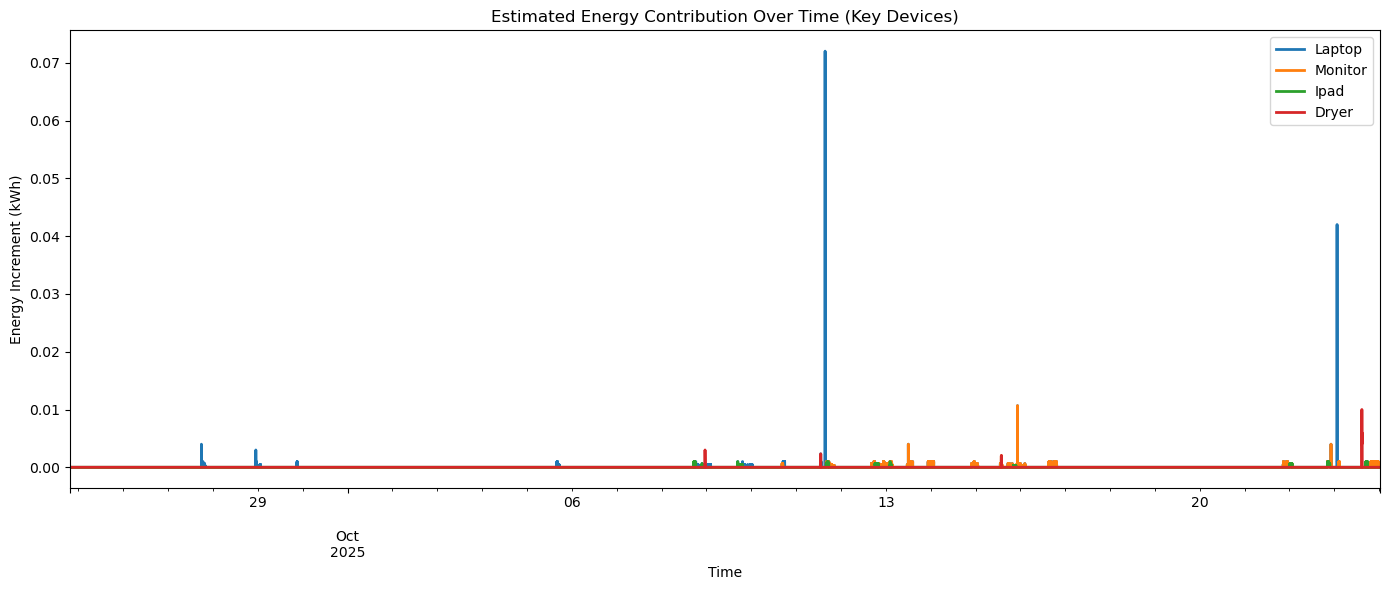

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------
# Load dataset
# ---------------------------
df = pd.read_excel('D:/Users/Rania/OneDrive - Universiti Teknologi PETRONAS/FYP/SmartTenaga/data/ml_ready_dataset_min2.xlsx')
df['created_at'] = pd.to_datetime(df['created_at'])

# Device columns
device_columns = ['laptop','phone','lamp','ipad','monitor','powerbank','dryer','earbuds']

# ---------------------------
# Step 1: Single-device timestamps
# ---------------------------
df_single_device = df[df['total_devices'] == 1]

device_stats = []
for dev in device_columns:
    df_dev = df_single_device[df_single_device[dev] == 1]
    total_power = df_dev['power'].sum()
    avg_power = df_dev['power'].mean()
    total_energy = df_dev['energy_increment_kwh'].sum()
    avg_energy = df_dev['energy_increment_kwh'].mean()
    count = len(df_dev)
    
    device_stats.append({
        'device': dev,
        'count_only_active': count,
        'total_power': total_power,
        'avg_power': avg_power,
        'total_energy_increment': total_energy,
        'avg_energy_increment': avg_energy
    })

device_stats_df = pd.DataFrame(device_stats).sort_values(by='total_energy_increment', ascending=False)
print("\n===== Device Stats (Single-Device Timestamps) =====")
print(device_stats_df)

# ---------------------------
# Step 2: Estimate contributions for multi-device timestamps
# ---------------------------
df_estimate = df.copy()
df_estimate['energy_per_device'] = df_estimate['energy_increment_kwh'] / df_estimate['total_devices'].replace(0,1)

# Optional: create per-device energy columns
for dev in device_columns:
    df_estimate[f'{dev}_energy_est'] = df_estimate[dev] * df_estimate['energy_per_device']

# ---------------------------
# Step 3: Visualizations
# ---------------------------

# 3a: Bar chart - Avg energy (single-device)
plt.figure(figsize=(8,5))
sns.barplot(x='device', y='avg_energy_increment', data=device_stats_df, palette='viridis')
plt.title("Average Energy Increment per Device (Single-Device Timestamps)")
plt.ylabel("Avg Energy Increment (kWh)")
plt.xlabel("Device")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 3b: Pie chart - Total energy (including multi-device estimates)
total_energy_per_device = df_estimate[[f'{dev}_energy_est' for dev in device_columns]].sum()
plt.figure(figsize=(7,7))
plt.pie(total_energy_per_device, labels=device_columns, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title("Estimated Total Energy Contribution by Device")
plt.tight_layout()
plt.show()

# 3c: Stacked line plot over time for key devices
key_devices = ['laptop','monitor','ipad','dryer']
df_estimate.set_index('created_at', inplace=True)
df_key = df_estimate[[f'{dev}_energy_est' for dev in key_devices]]
df_key_resampled = df_key.resample('1T').sum()  # resample to 1-minute intervals

df_key_resampled.plot(kind='line', figsize=(14,6), linewidth=2)
plt.title("Estimated Energy Contribution Over Time (Key Devices)")
plt.xlabel("Time")
plt.ylabel("Energy Increment (kWh)")
plt.legend([dev.capitalize() for dev in key_devices])
plt.tight_layout()
plt.show()


Dataset shape: (5063, 92)

Missing values:
created_at            0
voltage               0
current               0
power                 0
energy                0
                   ... 
delta_energy          0
apparent_power        0
pf_efficiency       129
date                  0
daily_energy_sum      0
Length: 92, dtype: int64

Data range: 2025-09-24 19:37:00 to 2025-10-24 00:26:00
SINGLE-DEVICE ENERGY ANALYSIS
Total timestamps: 5063
Single-device timestamps: 910 (18.0%)

Device Statistics (Single Device Active):
--------------------------------------------------------------------------------
laptop       | Count:  235 | Avg Power:  29.67W | Avg Energy: 0.001000kWh | Total Energy: 0.235000kWh
phone        | Count:  199 | Avg Power:  11.18W | Avg Energy: 0.000186kWh | Total Energy: 0.037000kWh
lamp         | Count:  149 | Avg Power:   4.51W | Avg Energy: 0.000074kWh | Total Energy: 0.011000kWh
ipad         | Count:   98 | Avg Power:  18.76W | Avg Energy: 0.000316kWh | Total Energy: 0

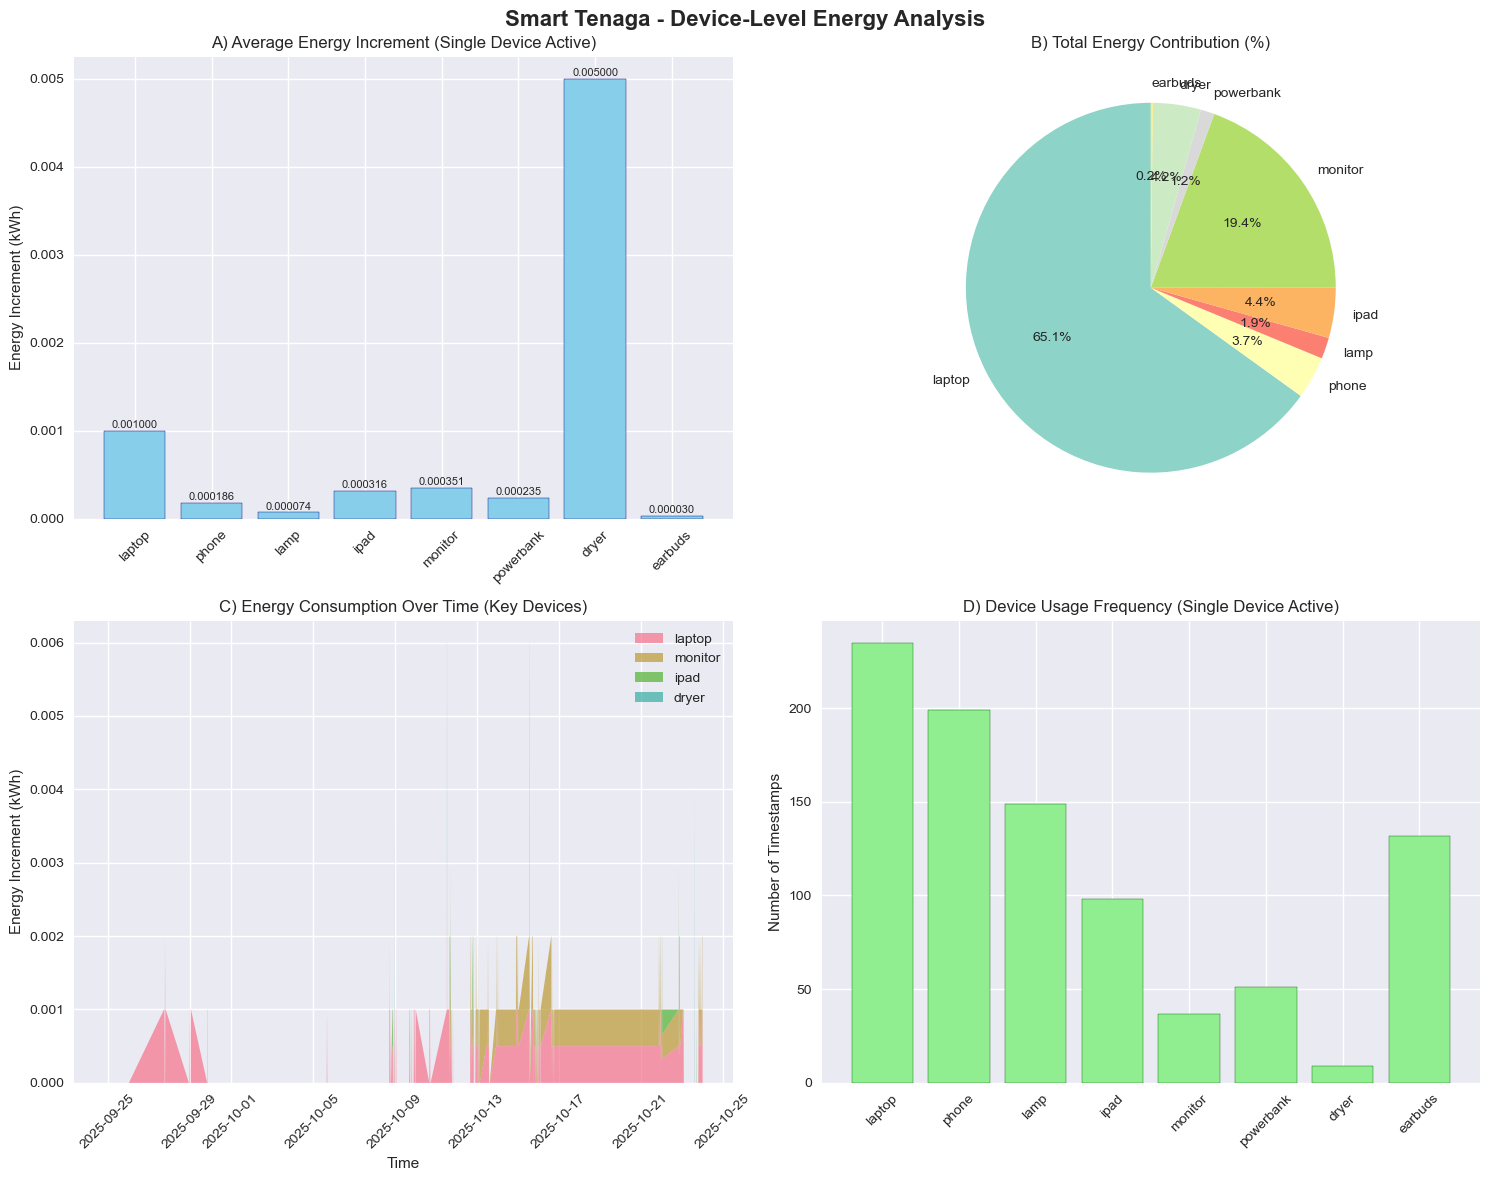


KEY INSIGHTS & RECOMMENDATIONS

HIGH-IMPACT DEVICES (by total energy consumption):
  1. laptop      : 2.717455 kWh
  2. monitor     : 0.811333 kWh
  3. ipad        : 0.183092 kWh
  4. dryer       : 0.175507 kWh
  5. phone       : 0.155232 kWh

USAGE PATTERNS:
  • Single-device scenarios: 0.388000 kWh
  • Multi-device scenarios: 3.789216 kWh

RECOMMENDATIONS FOR SMART TENAGA:
  1. Focus energy monitoring on high-impact devices
  2. Use single-device averages for baseline energy profiling
  3. Implement proportional allocation for multi-device scenarios
  4. Consider device-specific alerts for high-consumption devices
  5. Use these insights for ML feature engineering

ML FEATURE ENGINEERING SUGGESTIONS
Suggested features for predictive ML models:
  1. device_on_off_patterns
  2. expected_energy_based_on_active_devices
  3. device_combination_energy
  4. time_since_last_device_activation
  5. device_usage_duration
  6. energy_consumption_trends
  7. peak_usage_detection

Existing featur

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set up plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

class DeviceEnergyAnalyzer:
    def __init__(self, data_path):
        """Initialize the analyzer with the dataset"""
        self.df = pd.read_excel(data_path)
        self.device_columns = ['laptop', 'phone', 'lamp', 'ipad', 'monitor', 
                              'powerbank', 'dryer', 'earbuds']
        
    def preprocess_data(self):
        """Basic data preprocessing"""
        print("Dataset shape:", self.df.shape)
        print("\nMissing values:")
        print(self.df.isnull().sum())
        
        # Fill missing values if any
        self.df.fillna(0, inplace=True)
        
        # Ensure datetime format
        self.df['created_at'] = pd.to_datetime(self.df['created_at'])
        
        print(f"\nData range: {self.df['created_at'].min()} to {self.df['created_at'].max()}")
        
    def single_device_analysis(self):
        """Analyze energy usage when only one device is active"""
        print("=" * 60)
        print("SINGLE-DEVICE ENERGY ANALYSIS")
        print("=" * 60)
        
        # Filter rows where exactly one device is active
        device_sums = self.df[self.device_columns].sum(axis=1)
        single_device_mask = device_sums == 1
        single_device_df = self.df[single_device_mask].copy()
        
        print(f"Total timestamps: {len(self.df)}")
        print(f"Single-device timestamps: {len(single_device_df)} ({len(single_device_df)/len(self.df)*100:.1f}%)")
        
        # Initialize results dictionary
        device_stats = {}
        
        for device in self.device_columns:
            # Filter rows where only this device is active
            device_mask = (single_device_df[device] == 1)
            device_data = single_device_df[device_mask]
            
            count_active = len(device_data)
            
            if count_active > 0:
                avg_power = device_data['power'].mean()
                avg_energy_inc = device_data['energy_increment_kwh'].mean()
                total_power = device_data['power'].sum()
                total_energy_inc = device_data['energy_increment_kwh'].sum()
                
                device_stats[device] = {
                    'count_only_active': count_active,
                    'avg_power': avg_power,
                    'avg_energy_increment': avg_energy_inc,
                    'total_power': total_power,
                    'total_energy_increment': total_energy_inc,
                    'percentage_of_single_device_time': (count_active / len(single_device_df)) * 100
                }
            else:
                device_stats[device] = {
                    'count_only_active': 0,
                    'avg_power': 0,
                    'avg_energy_increment': 0,
                    'total_power': 0,
                    'total_energy_increment': 0,
                    'percentage_of_single_device_time': 0
                }
        
        # Convert to DataFrame for easier analysis
        stats_df = pd.DataFrame(device_stats).T
        stats_df = stats_df.sort_values('avg_energy_increment', ascending=False)
        
        print("\nDevice Statistics (Single Device Active):")
        print("-" * 80)
        for device, stats in device_stats.items():
            if stats['count_only_active'] > 0:
                print(f"{device:12} | "
                      f"Count: {stats['count_only_active']:4d} | "
                      f"Avg Power: {stats['avg_power']:6.2f}W | "
                      f"Avg Energy: {stats['avg_energy_increment']:8.6f}kWh | "
                      f"Total Energy: {stats['total_energy_increment']:8.6f}kWh")
        
        return device_stats, stats_df
    
    def multi_device_energy_allocation(self, device_stats):
        """Allocate energy for multi-device timestamps using proportional allocation"""
        print("\n" + "=" * 60)
        print("MULTI-DEVICE ENERGY ALLOCATION")
        print("=" * 60)
        
        # Get single-device averages for weights
        device_avgs = {device: max(stats['avg_energy_increment'], 0.000001)  # Avoid division by zero
                      for device, stats in device_stats.items()}
        
        # Filter multi-device timestamps
        device_sums = self.df[self.device_columns].sum(axis=1)
        multi_device_mask = device_sums > 1
        multi_device_df = self.df[multi_device_mask].copy()
        
        print(f"Multi-device timestamps: {len(multi_device_df)} ({len(multi_device_df)/len(self.df)*100:.1f}%)")
        
        # Initialize allocation results
        allocated_energy = {device: 0 for device in self.device_columns}
        allocation_records = []
        
        for idx, row in multi_device_df.iterrows():
            active_devices = [device for device in self.device_columns if row[device] == 1]
            total_energy = row['energy_increment_kwh']
            
            if len(active_devices) == 0:
                continue
                
            # Get weights for active devices
            active_weights = [device_avgs[device] for device in active_devices]
            total_weight = sum(active_weights)
            
            # Fallback: if all weights are zero, split evenly
            if total_weight == 0:
                energy_per_device = total_energy / len(active_devices)
                for device in active_devices:
                    allocated_energy[device] += energy_per_device
            else:
                # Proportional allocation
                for device in active_devices:
                    proportion = device_avgs[device] / total_weight
                    device_energy = total_energy * proportion
                    allocated_energy[device] += device_energy
            
            # Store allocation for this timestamp
            allocation_record = {'timestamp': row['created_at'], 'total_energy': total_energy}
            for device in active_devices:
                proportion = device_avgs[device] / total_weight if total_weight > 0 else 1/len(active_devices)
                allocation_record[f'{device}_allocated'] = total_energy * proportion
            allocation_records.append(allocation_record)
        
        # Combine single-device and multi-device energy
        total_allocated_energy = {}
        for device in self.device_columns:
            single_energy = device_stats[device]['total_energy_increment']
            multi_energy = allocated_energy[device]
            total_allocated_energy[device] = single_energy + multi_energy
        
        print("\nTotal Energy Allocation (Single + Multi-device):")
        print("-" * 50)
        for device, energy in sorted(total_allocated_energy.items(), key=lambda x: x[1], reverse=True):
            print(f"{device:12}: {energy:10.6f} kWh")
        
        return total_allocated_energy, pd.DataFrame(allocation_records)

    def multi_device_energy_allocation_weighted(self, device_stats):
        """Allocate energy for multi-device timestamps using weighted single-device averages"""
        print("\n" + "=" * 60)
        print("MULTI-DEVICE ENERGY ALLOCATION (WEIGHTED)")
        print("=" * 60)
        
        # Map each device to its single-device average energy
        avg_energy_map = {device: max(stats['avg_energy_increment'], 0.000001)  # avoid zero
                          for device, stats in device_stats.items()}
        
        # Filter multi-device timestamps
        device_sums = self.df[self.device_columns].sum(axis=1)
        multi_device_mask = device_sums > 1
        df_multi = self.df[multi_device_mask].copy()
        
        print(f"Multi-device timestamps: {len(df_multi)} ({len(df_multi)/len(self.df)*100:.1f}%)")
        
        # Weighted allocation per row
        def weighted_energy(row):
            active = [dev for dev in self.device_columns if row[dev] == 1]
            if not active:
                return pd.Series({f'{dev}_energy_est': 0 for dev in self.device_columns})
            total_avg = sum([avg_energy_map[d] for d in active])
            return pd.Series({f'{dev}_energy_est': (avg_energy_map[dev] / total_avg) * row['energy_increment_kwh']
                              if dev in active else 0 for dev in self.device_columns})
        
        df_weighted = df_multi.apply(weighted_energy, axis=1)
        
        # Sum weighted energy per device
        allocated_energy = {dev: df_weighted[dev+'_energy_est'].sum() for dev in self.device_columns}
        
        # Add single-device totals
        total_allocated_energy = {}
        for dev in self.device_columns:
            single_energy = device_stats[dev]['total_energy_increment']
            multi_energy = allocated_energy[dev]
            total_allocated_energy[dev] = single_energy + multi_energy
        
        print("\nTotal Weighted Energy Allocation (Single + Multi-device):")
        print("-" * 50)
        for device, energy in sorted(total_allocated_energy.items(), key=lambda x: x[1], reverse=True):
            print(f"{device:12}: {energy:10.6f} kWh")
        
        return total_allocated_energy, df_weighted


    
    
    def create_visualizations(self, device_stats, total_allocated_energy, stats_df):
        """Create comprehensive visualizations"""
        print("\n" + "=" * 60)
        print("CREATING VISUALIZATIONS")
        print("=" * 60)
        
        fig, axes = plt.subplots(2, 2, figsize=(15, 12))
        fig.suptitle('Smart Tenaga - Device-Level Energy Analysis', fontsize=16, fontweight='bold')
        
        # 1. Bar chart: Average energy increment per device (single-device)
        devices = [d for d in self.device_columns if device_stats[d]['count_only_active'] > 0]
        avg_energy = [device_stats[d]['avg_energy_increment'] for d in devices]
        
        axes[0, 0].bar(devices, avg_energy, color='skyblue', edgecolor='navy')
        axes[0, 0].set_title('A) Average Energy Increment (Single Device Active)')
        axes[0, 0].set_ylabel('Energy Increment (kWh)')
        axes[0, 0].tick_params(axis='x', rotation=45)
        
        # Add value labels on bars
        for i, v in enumerate(avg_energy):
            axes[0, 0].text(i, v + 0.00001, f'{v:.6f}', ha='center', va='bottom', fontsize=8)
        
        # 2. Pie chart: Total energy contribution
        total_energy_by_device = {k: v for k, v in total_allocated_energy.items() if v > 0}
        
        # Group low-usage devices
        threshold = 0.001  # kWh threshold for grouping
        main_devices = {k: v for k, v in total_energy_by_device.items() if v >= threshold}
        other_energy = sum(v for k, v in total_energy_by_device.items() if v < threshold)
        
        if other_energy > 0:
            main_devices['Other'] = other_energy
        
        colors = plt.cm.Set3(np.linspace(0, 1, len(main_devices)))
        wedges, texts, autotexts = axes[0, 1].pie(main_devices.values(), labels=main_devices.keys(), 
                                                 autopct='%1.1f%%', colors=colors, startangle=90)
        axes[0, 1].set_title('B) Total Energy Contribution (%)')
        
        # 3. Stacked area plot: Energy over time for key devices
        key_devices = ['laptop', 'monitor', 'ipad', 'dryer']
        
        # Create time series data for key devices
        time_series_data = self.df[['created_at'] + key_devices + ['energy_increment_kwh']].copy()
        
        # Sample for better visualization if dataset is large
        if len(time_series_data) > 1000:
            time_series_data = time_series_data.iloc[::len(time_series_data)//1000]
        
        # Create stacked plot
        for device in key_devices:
            # Simple estimation: divide energy equally among active devices at each timestamp
            device_energy_estimate = []
            for idx, row in time_series_data.iterrows():
                active_count = sum(row[device] for device in key_devices)
                if active_count > 0 and row[device] == 1:
                    device_energy_estimate.append(row['energy_increment_kwh'] / active_count)
                else:
                    device_energy_estimate.append(0)
            
            time_series_data[f'{device}_energy'] = device_energy_estimate
        
        # Plot stacked area
        energy_columns = [f'{device}_energy' for device in key_devices]
        axes[1, 0].stackplot(time_series_data['created_at'], 
                            [time_series_data[col] for col in energy_columns],
                            labels=key_devices, alpha=0.7)
        axes[1, 0].set_title('C) Energy Consumption Over Time (Key Devices)')
        axes[1, 0].set_ylabel('Energy Increment (kWh)')
        axes[1, 0].set_xlabel('Time')
        axes[1, 0].legend()
        axes[1, 0].tick_params(axis='x', rotation=45)
        
        # 4. Device usage frequency
        usage_counts = [device_stats[d]['count_only_active'] for d in self.device_columns]
        axes[1, 1].bar(self.device_columns, usage_counts, color='lightgreen', edgecolor='darkgreen')
        axes[1, 1].set_title('D) Device Usage Frequency (Single Device Active)')
        axes[1, 1].set_ylabel('Number of Timestamps')
        axes[1, 1].tick_params(axis='x', rotation=45)
        
        plt.tight_layout()
        plt.show()
        
        # Additional summary statistics
        self.print_summary_statistics(device_stats, total_allocated_energy)
    
    def print_summary_statistics(self, device_stats, total_allocated_energy):
        """Print key insights and statistics"""
        print("\n" + "=" * 60)
        print("KEY INSIGHTS & RECOMMENDATIONS")
        print("=" * 60)
        
        # Identify high-impact devices
        high_impact = [(device, energy) for device, energy in total_allocated_energy.items() 
                      if energy > 0.001]  # Threshold for high impact
        
        if high_impact:
            high_impact_sorted = sorted(high_impact, key=lambda x: x[1], reverse=True)
            print("\nHIGH-IMPACT DEVICES (by total energy consumption):")
            for i, (device, energy) in enumerate(high_impact_sorted[:5], 1):
                print(f"  {i}. {device:12}: {energy:.6f} kWh")
        
        # Usage patterns
        total_single_device_energy = sum(stats['total_energy_increment'] for stats in device_stats.values())
        print(f"\nUSAGE PATTERNS:")
        print(f"  • Single-device scenarios: {total_single_device_energy:.6f} kWh")
        print(f"  • Multi-device scenarios: {sum(total_allocated_energy.values()) - total_single_device_energy:.6f} kWh")
        
        # Recommendations
        print(f"\nRECOMMENDATIONS FOR SMART TENAGA:")
        print("  1. Focus energy monitoring on high-impact devices")
        print("  2. Use single-device averages for baseline energy profiling")
        print("  3. Implement proportional allocation for multi-device scenarios")
        print("  4. Consider device-specific alerts for high-consumption devices")
        print("  5. Use these insights for ML feature engineering")
    
    def generate_ml_features(self):
        """Generate additional features for ML models"""
        print("\n" + "=" * 60)
        print("ML FEATURE ENGINEERING SUGGESTIONS")
        print("=" * 60)
        
        suggested_features = [
            "device_on_off_patterns",
            "expected_energy_based_on_active_devices", 
            "device_combination_energy",
            "time_since_last_device_activation",
            "device_usage_duration",
            "energy_consumption_trends",
            "peak_usage_detection"
        ]
        
        print("Suggested features for predictive ML models:")
        for i, feature in enumerate(suggested_features, 1):
            print(f"  {i}. {feature}")
        
        print("\nExisting features in dataset that are ML-ready:")
        ml_ready_features = ['power_lag1', 'power_lag2', 'power_rolling_mean_3', 
                           'power_rolling_std_3', 'energy_increment_kwh_lag1',
                           'hour_sin', 'hour_cos', 'day_of_week_sin', 'day_of_week_cos']
        for feature in ml_ready_features[:5]:  # Show first 5
            print(f"  • {feature}")
        
        return suggested_features

# Main execution
def main():
    # Initialize analyzer
    analyzer = DeviceEnergyAnalyzer('D:/Users/Rania/OneDrive - Universiti Teknologi PETRONAS/FYP/SmartTenaga/data/ml_ready_dataset_min2.xlsx')
    
    # Preprocess data
    analyzer.preprocess_data()
    
    # Single-device analysis
    device_stats, stats_df = analyzer.single_device_analysis()
    
    # Multi-device energy allocation
    total_allocated_energy, allocation_df = analyzer.multi_device_energy_allocation(device_stats)

    # # Multi-device energy allocation (weighted)
    # total_allocated_energy, allocation_df = analyzer.multi_device_energy_allocation_weighted(device_stats)

    
    # Create visualizations
    analyzer.create_visualizations(device_stats, total_allocated_energy, stats_df)
    
    # Generate ML features suggestions
    analyzer.generate_ml_features()
    
    # Return results for further analysis
    return analyzer, device_stats, total_allocated_energy, stats_df, allocation_df

# Run the analysis
if __name__ == "__main__":
    analyzer, device_stats, total_allocated_energy, stats_df, allocation_df = main()